In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set()

%config InlineBackend.figure_format ="svg"

In [14]:
file_path = r"C:\Users\ahmad\Desktop\Investing\Jose-Portilla-Python for Time Series Analysis\UDEMY_TSA_FINAL\UDEMY_TSA_FINAL\Data"
df = pd.read_csv(file_path+r"\airline_passengers.csv", parse_dates=[0], index_col=[0])
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [15]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [16]:
df.index.freq = "MS"

In [17]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [18]:
span = 12 
alpha = 2 / (span + 1 )

In [19]:
df["EWMA_S"] = df["Thousands of Passengers"].ewm(span=span, adjust=False).mean()
# or df["EWMA_S2"] = df["Thousands of Passengers"].ewm(alpha=alpha, adjust=False).mean()

In [20]:
df

,Thousands of Passengers,EWMA_S
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.923077
1949-03-01,132,115.857988
1949-04-01,129,117.879836
1949-05-01,121,118.359861
...,...,...
1960-08-01,606,494.898619
1960-09-01,508,496.914216
1960-10-01,461,491.388952


##### Simple Exponential Smoothing

In [21]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [23]:
model = SimpleExpSmoothing(endog=df["Thousands of Passengers"])
fitted_model = model.fit(smoothing_level=alpha, optimized=False)
df["SES"] = fitted_model.fittedvalues.shift(-1) # SimpleExpSmoothing values

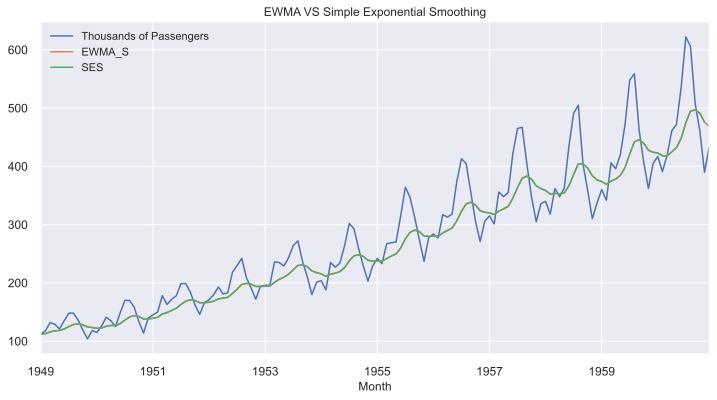

In [25]:
df.plot(figsize=(12, 6), title="EWMA VS Simple Exponential Smoothing", fontsize=12)
plt.show()

#### Double Exponnetial Smoothing 

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
span = 12 
alpha = 2 / (span + 1 )

In [48]:
df["DES_S"] = (
    ExponentialSmoothing(endog=df["Thousands of Passengers"], trend="mul").
    fit().
    fittedvalues.
    shift(-1)
    )

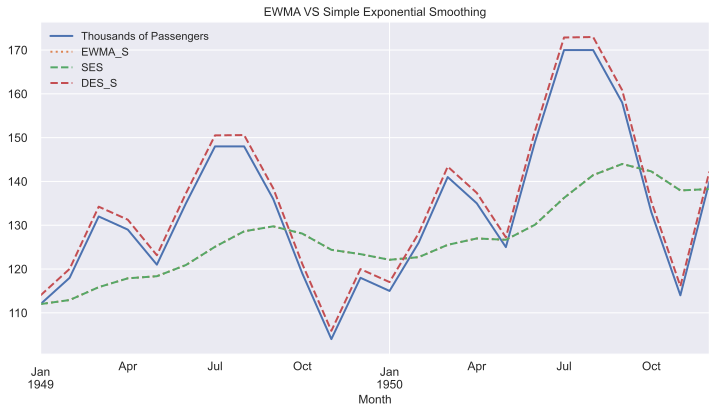

In [69]:
df.loc["1949":"1950"].plot(figsize=(12, 6), 
                           title="EWMA VS Simple Exponential Smoothing", 
                           fontsize=12, 
                           style= ["-",":","--","--"] , 
                           lw =2)
plt.show()

##### Triple Exponential Smoothing: we will add the third parameters seasonal to ExponentialSmoothing

In [76]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
span = 12 
alpha = 2 / (span + 1 )

In [ ]:
df["TES_S"] = ExponentialSmoothing(endog=df["Thousands of Passengers"], trend="mul", seasonal="mul", seasonal_periods=12).fit().fittedvalues.shift(-1)

c:\Users\ahmad\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


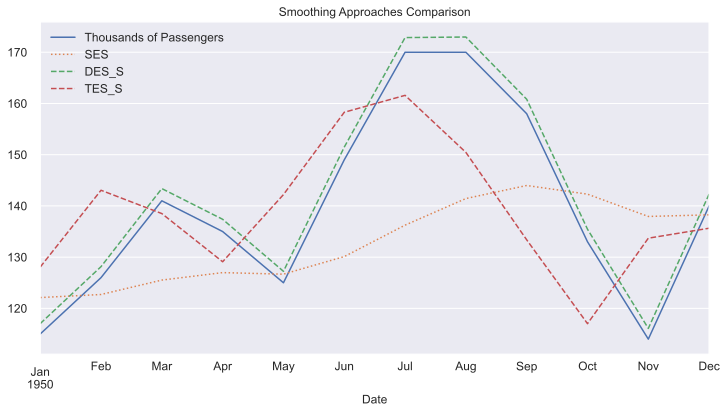

In [86]:
df.loc["1950", ["Thousands of Passengers", "SES","DES_S","TES_S"]].plot(figsize=(12, 6), 
                                                                        title="Smoothing Approaches Comparison", 
                                                                        style = ["-",":","--","--"],
                                                                        fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc = "best", fontsize=12, fancybox=True)
plt.show()